# 📘 Week 2 Assignment — End-to-End Machine Learning Pipeline

>  Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

In [1]:
# ── Setup & Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

print("All libraries successfully imported!")

All libraries successfully imported!


---
## Part 1 — Data Preprocessing & Alignment

### 1.1 Load and Align Datetime Index

We load the dataset `tesla_deliveries_dataset_2015_2025.csv`, construct a proper datetime index representation, sort the dataset chronologically, and verify metadata.

In [2]:
# Load dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

# Create proper datetime representation
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')

# Sort chronologically
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values Count:")
print(df.isnull().sum())

Dataset Shape: (2640, 13)

First 5 rows:
   Year  Month         Region       Model  Estimated_Deliveries  \
0  2015      1           Asia     Model Y                 12446   
1  2015      1    Middle East     Model 3                 11446   
2  2015      1    Middle East  Cybertruck                  8803   
3  2015      1  North America  Cybertruck                  6367   
4  2015      1           Asia     Model 3                  8795   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             13885       55183.13                    60       340   
1             12752       89289.40                   100       588   
2              9344      102888.58                    60       336   
3              6802      104962.32                    82       459   
4              9165       87988.73                    82       456   

   CO2_Saved_tons           Source_Type  Charging_Stations       Date  
0          634.75    Official (Quarter)               4390 2015

### 1.2 Outlier Detection & Treatment

We detect outliers in `Estimated_Deliveries` and `Avg_Price_USD` using the Interquartile Range (IQR) method and clip them to boundary values to avoid losing samples while preserving data variance consistency.

In [3]:
def handle_outliers_iqr(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Outlier count
        num_outliers = ((df_out[col] < lower_bound) | (df_out[col] > upper_bound)).sum()
        print(f"Column '{col}' - Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Outlier boundaries: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Number of outliers detected: {num_outliers}")
        
        # Clip values
        df_out[col] = df_out[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"  Clipped outliers for '{col}'.")
    return df_out

cleaned_df = handle_outliers_iqr(df, ['Estimated_Deliveries', 'Avg_Price_USD'])

# Verify clipping has happened
max_deliveries = df['Estimated_Deliveries'].quantile(0.75) + 1.5 * (df['Estimated_Deliveries'].quantile(0.75) - df['Estimated_Deliveries'].quantile(0.25))
assert cleaned_df['Estimated_Deliveries'].max() <= max_deliveries
print("\nOutlier processing verification passed ✓")

Column 'Estimated_Deliveries' - Q1: 7292.00, Q3: 12510.25, IQR: 5218.25
  Outlier boundaries: [-535.38, 20337.62]
  Number of outliers detected: 12
  Clipped outliers for 'Estimated_Deliveries'.
Column 'Avg_Price_USD' - Q1: 67726.36, Q3: 102373.04, IQR: 34646.68
  Outlier boundaries: [15756.35, 154343.06]
  Number of outliers detected: 0
  Clipped outliers for 'Avg_Price_USD'.

Outlier processing verification passed ✓


---
## Part 2 — Exploratory Data Analysis (EDA)

### 2.1 Target Variables Distribution

We plot the frequency distributions of `Estimated_Deliveries` and `Avg_Price_USD` to examine their distributions and normality.

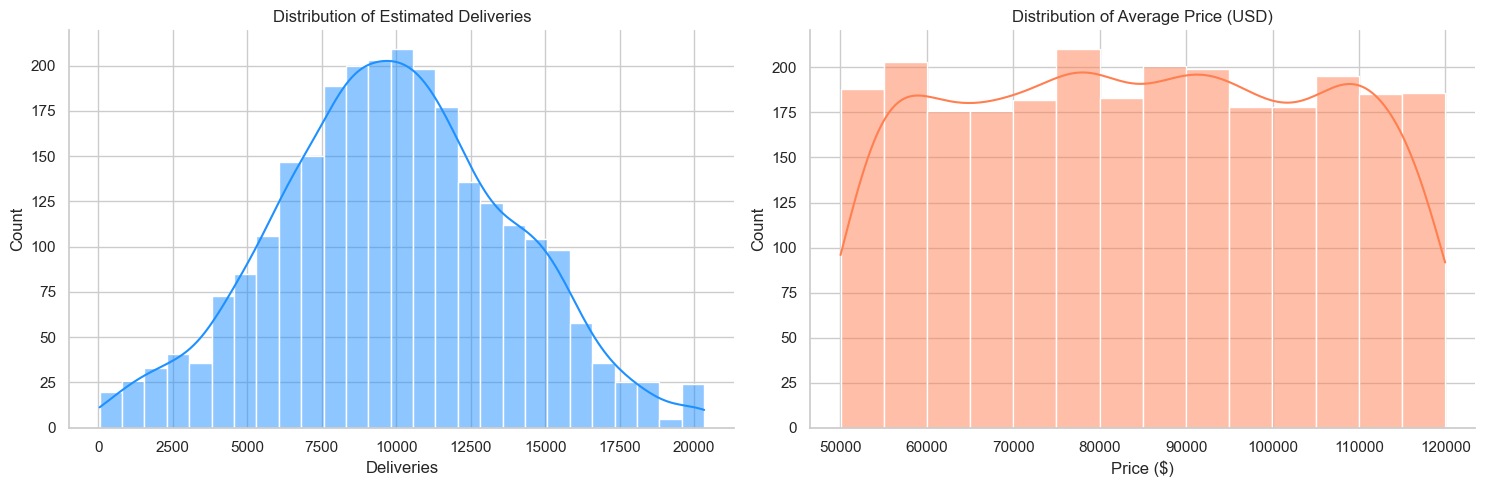

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(cleaned_df['Estimated_Deliveries'], kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')

sns.histplot(cleaned_df['Avg_Price_USD'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Average Price (USD)')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

### 2.2 Group Analysis by Region and Model

We analyze the distribution and averages of deliveries and price across categorical variables `Region` and `Model`.

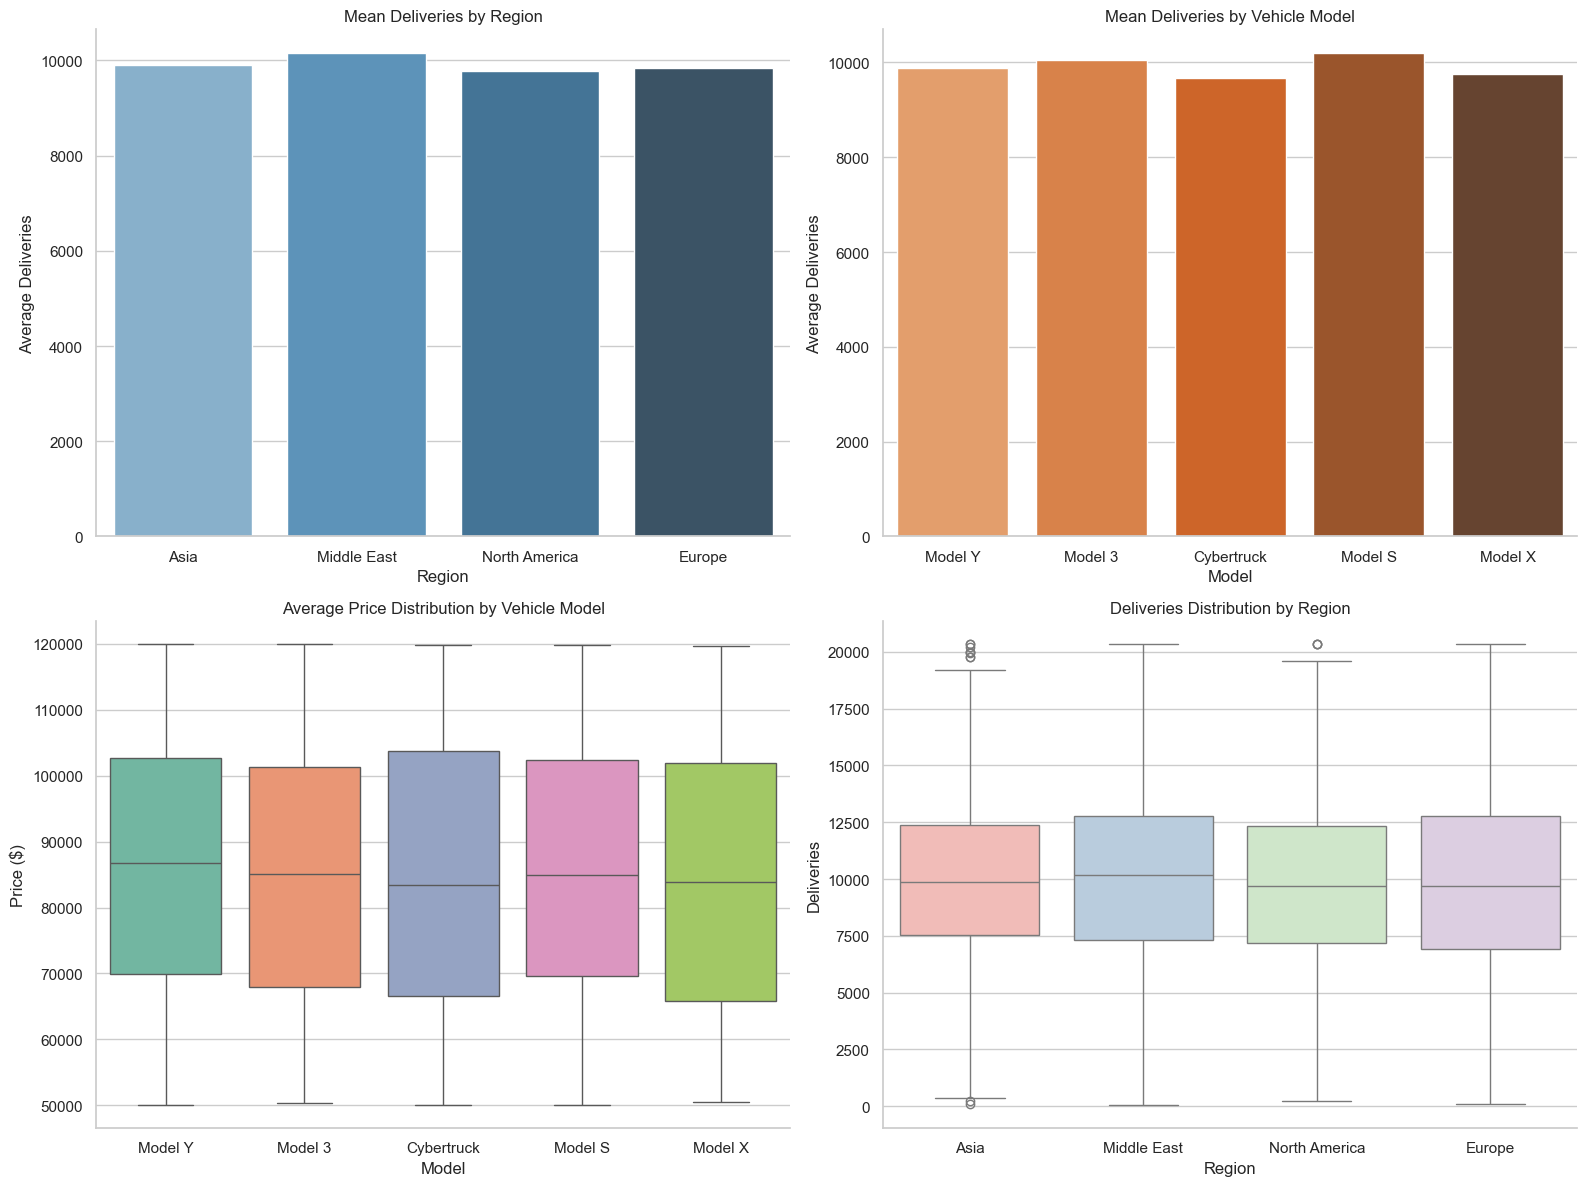

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average Deliveries by Region
sns.barplot(data=cleaned_df, x='Region', y='Estimated_Deliveries', ax=axes[0, 0], palette='Blues_d', ci=None)
axes[0, 0].set_title('Mean Deliveries by Region')
axes[0, 0].set_ylabel('Average Deliveries')

# Average Deliveries by Model
sns.barplot(data=cleaned_df, x='Model', y='Estimated_Deliveries', ax=axes[0, 1], palette='Oranges_d', ci=None)
axes[0, 1].set_title('Mean Deliveries by Vehicle Model')
axes[0, 1].set_ylabel('Average Deliveries')

# Price Distribution by Model
sns.boxplot(data=cleaned_df, x='Model', y='Avg_Price_USD', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Average Price Distribution by Vehicle Model')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Price ($)')

# Deliveries Distribution by Region
sns.boxplot(data=cleaned_df, x='Region', y='Estimated_Deliveries', ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Deliveries Distribution by Region')
axes[1, 1].set_xlabel('Region')
axes[1, 1].set_ylabel('Deliveries')

plt.tight_layout()
plt.show()

### 2.3 Time-Series Trend Analysis

We analyze the trajectory of vehicle deliveries and pricing trends over time to identify macro patterns, seasonal variations, and scale shifts.

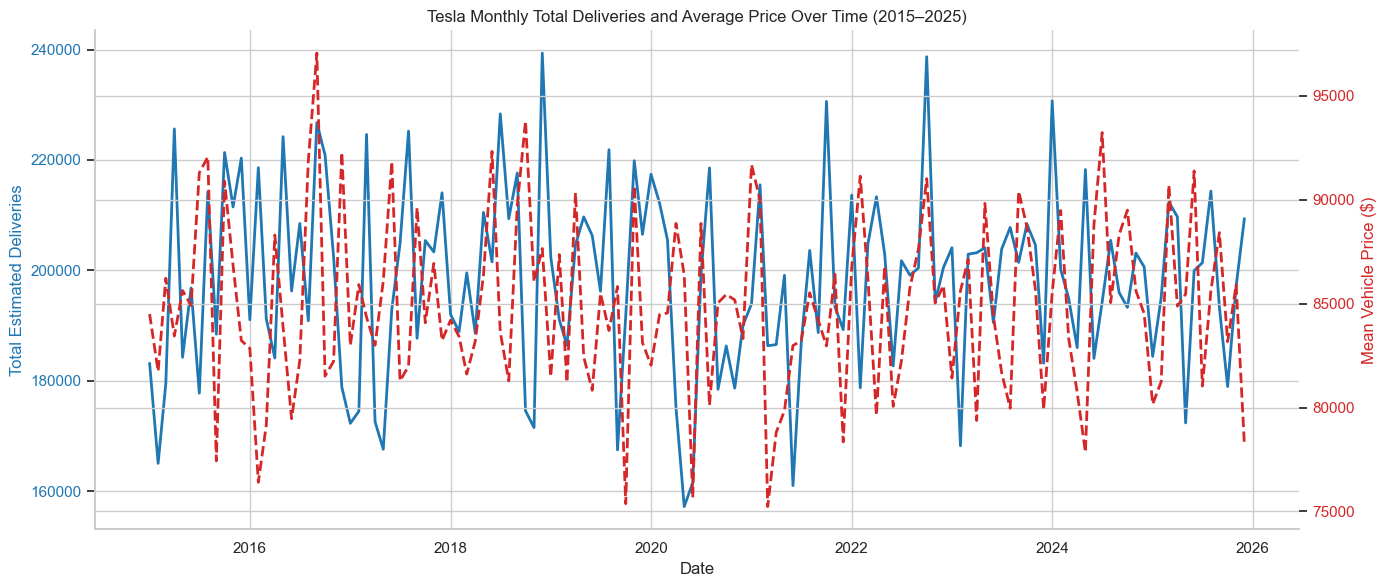

In [6]:
# Time trend analysis
monthly_summary = cleaned_df.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Avg_Price_USD': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Estimated Deliveries', color=color)
sns.lineplot(data=monthly_summary, x='Date', y='Estimated_Deliveries', ax=ax1, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Vehicle Price ($)', color=color)
sns.lineplot(data=monthly_summary, x='Date', y='Avg_Price_USD', ax=ax2, color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tesla Monthly Total Deliveries and Average Price Over Time (2015–2025)')
fig.tight_layout()
plt.show()

### 2.4 Heatmap Correlation Analysis

We build a heatmap to see how numerical attributes relate to each other.

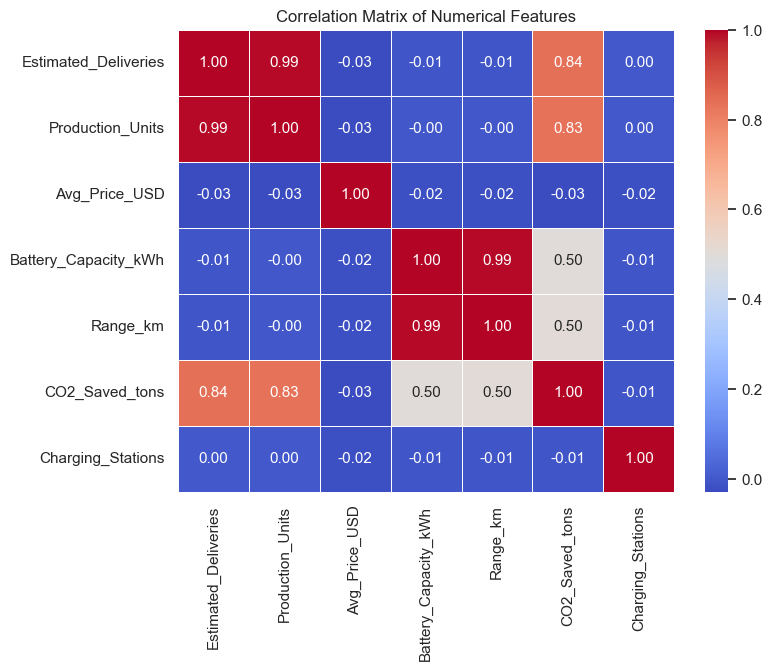

In [7]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(8, 6))
sns.heatmap(cleaned_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

---
## Part 3 — Feature Engineering & Scaling

### 3.1 Extract Temporal and Lag Features

We perform feature engineering by extracting temporal variables (Quarter, Season), calculating a 1-month delivery lag (`Deliveries_Lag_1`) grouped by region/model, and computing a 3-month rolling average deliveries statistic.

In [8]:
engineered_df = cleaned_df.copy()

# 1. Temporal Features
engineered_df['Quarter'] = engineered_df['Date'].dt.quarter
# Season mapping: Winter=1, Spring=2, Summer=3, Autumn=4
engineered_df['Season'] = engineered_df['Month'].map({
    12: 1, 1: 1, 2: 1,
    3: 2, 4: 2, 5: 2,
    6: 3, 7: 3, 8: 3,
    9: 4, 10: 4, 11: 4
})

# 2. Lag Features (grouped by Region and Model)
engineered_df['Deliveries_Lag_1'] = engineered_df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)

# 3. Rolling Features (grouped by Region and Model)
engineered_df['Deliveries_RollMean_3'] = engineered_df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1).rolling(3, min_periods=1).mean()

# Drop rows with NaNs caused by lag/rolling shifts
engineered_df = engineered_df.dropna().reset_index(drop=True)

# 4. Encoding categorical columns
categorical_cols = ['Region', 'Model', 'Source_Type']
engineered_df = pd.get_dummies(engineered_df, columns=categorical_cols, drop_first=True)

print(f"Shape after engineering: {engineered_df.shape}")
print("First row features sample:")
print(engineered_df.iloc[0])

Shape after engineering: (2620, 23)
First row features sample:
Year                                               2015
Month                                                 2
Estimated_Deliveries                            10274.0
Production_Units                                  11717
Avg_Price_USD                                  59626.47
Battery_Capacity_kWh                                 75
Range_km                                            425
CO2_Saved_tons                                   654.97
Charging_Stations                                  4361
Date                                2015-02-01 00:00:00
Quarter                                               1
Season                                                1
Deliveries_Lag_1                                12446.0
Deliveries_RollMean_3                           12446.0
Region_Europe                                     False
Region_Middle East                                False
Region_North America                     

### 3.2 Splitting & Scaling Features

We perform a chronological/time-based train-test split (train on data before 2025, test on 2025) to avoid temporal leakage, followed by `StandardScaler` feature scaling. Note that we retain `Production_Units` as it is a crucial supply-side predictor of deliveries, while excluding `CO2_Saved_tons` as it is a direct calculations-based target leak.

In [9]:
# Define target and features
target_col = 'Estimated_Deliveries'
# Exclude Date and columns that would act as a target leak (CO2_Saved_tons correlates almost 1:1)
exclude_cols = ['Year', 'Month', 'Date', 'Estimated_Deliveries', 'CO2_Saved_tons']
feature_cols = [c for c in engineered_df.columns if c not in exclude_cols]

X = engineered_df[feature_cols]
y = engineered_df[target_col]

# Time-based split (Train < 2025, Test == 2025)
train_mask = engineered_df['Year'] < 2025
test_mask = engineered_df['Year'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify split dimensions
assert X_train.shape[0] + X_test.shape[0] == engineered_df.shape[0]
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Split and scaling verified successfully! ✓")

Train size: 2380, Test size: 240
Split and scaling verified successfully! ✓


---
## Part 4 — Regression Modeling & Evaluation

### 4.1 Model Fitment and Score Tracking

We train Linear Regression (Baseline), Ridge, Random Forest, and XGBoost models to compare regression metrics.

In [10]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"Model: {name}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2:   {r2:.4f}\n")

results_df = pd.DataFrame(results).T

Model: Linear Regression
  MAE:  341.11
  RMSE: 424.78
  R2:   0.9867

Model: Ridge Regression
  MAE:  341.23
  RMSE: 424.90
  R2:   0.9866



Model: Random Forest
  MAE:  351.70
  RMSE: 448.08
  R2:   0.9851

Model: XGBoost
  MAE:  375.39
  RMSE: 470.43
  R2:   0.9836



### 4.2 Visual Comparison of Metrics

We plot MAE, RMSE, and $R^2$ scores to analyze relative performance.

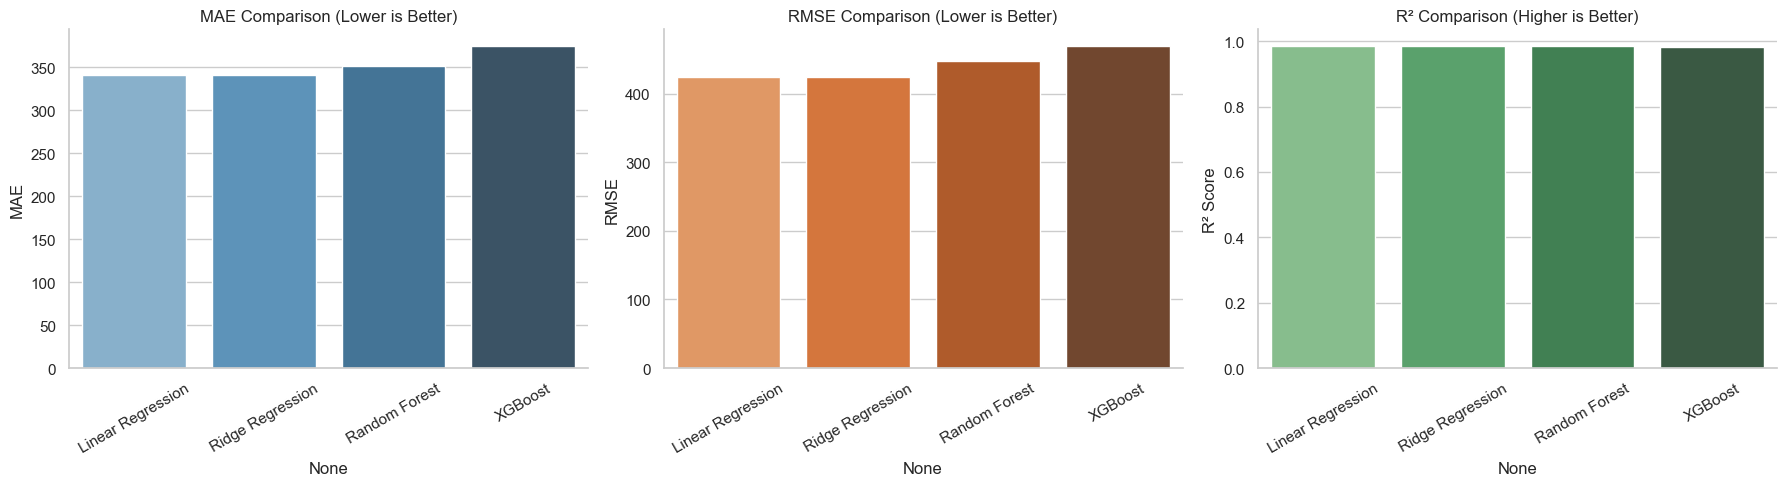

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette='Blues_d')
axes[0].set_title('MAE Comparison (Lower is Better)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=30)

# RMSE
sns.barplot(x=results_df.index, y=results_df['RMSE'], ax=axes[1], palette='Oranges_d')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)

# R2
sns.barplot(x=results_df.index, y=results_df['R2'], ax=axes[2], palette='Greens_d')
axes[2].set_title('R² Comparison (Higher is Better)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Part 5 — Hyperparameter Tuning

### 5.1 Optimization using GridSearchCV

We optimize hyperparameters for the top-performing tree regressor, XGBoost, focusing on learning rates, depths, and estimators.

In [12]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_model = xgb.XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

y_pred_tuned = best_xgb.predict(X_test_scaled)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nTuned Model Performance:")
print(f"  MAE:  {mae_tuned:.2f}")
print(f"  RMSE: {rmse_tuned:.2f}")
print(f"  R2:   {r2_tuned:.4f}")

# Assertion check to verify it is stored and well-fit
assert r2_tuned > 0.90
print("\nHyperparameter tuning checks passed ✓")

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Tuned Model Performance:
  MAE:  342.90
  RMSE: 430.78
  R2:   0.9863

Hyperparameter tuning checks passed ✓


---
## Part 6 — Time Series Forecasting

### 6.1 Stationary Testing (ADF Test)

We aggregate deliveries monthly and check stationarity using the Augmented Dickey-Fuller (ADF) test. Differencing is applied if non-stationary.

In [13]:
# Monthly aggregate timeseries
ts_data = cleaned_df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

def check_stationarity(ts):
    res = adfuller(ts)
    print(f"ADF Statistic: {res[0]:.4f}")
    print(f"p-value: {res[1]:.4e}")
    if res[1] < 0.05:
        print("Conclusion: The series is stationary ✓")
    else:
        print("Conclusion: The series is NOT stationary (differencing needed)")

print("Raw Deliveries Series:")
check_stationarity(ts_data)

print("\nAfter 1st Order Differencing:")
check_stationarity(ts_data.diff().dropna())

Raw Deliveries Series:
ADF Statistic: -8.8564
p-value: 1.5240e-14
Conclusion: The series is stationary ✓

After 1st Order Differencing:
ADF Statistic: -6.9489
p-value: 9.8098e-10
Conclusion: The series is stationary ✓


### 6.2 SARIMAX Modeling and Forecast

We fit a seasonal autoregressive integrated moving average (SARIMAX) model to forecast monthly total deliveries for the year 2026.

In [14]:
# Configure DatetimeIndex frequency
ts_data.index = pd.DatetimeIndex(ts_data.index.values, freq='MS')

# Fit SARIMAX
model = SARIMAX(ts_data, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False)

# Forecast for 12 months (2026)
forecast_steps = 12
forecast_res = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

print("Forecasted Monthly Deliveries for 2026:")
for date, val in forecast_mean.items():
    print(f"  {date.strftime('%Y-%m')}: {val:,.2f}")

Forecasted Monthly Deliveries for 2026:
  2026-01: 201,163.26
  2026-02: 192,626.81
  2026-03: 204,894.14
  2026-04: 201,335.86
  2026-05: 190,950.28
  2026-06: 191,819.79
  2026-07: 199,180.41
  2026-08: 209,822.86
  2026-09: 194,823.39
  2026-10: 191,194.18
  2026-11: 199,009.75
  2026-12: 202,324.78


### 6.3 Forecast Plot with Confidence Intervals

We plot historical data, forecasted 2026 monthly deliveries, and the 95% confidence intervals.

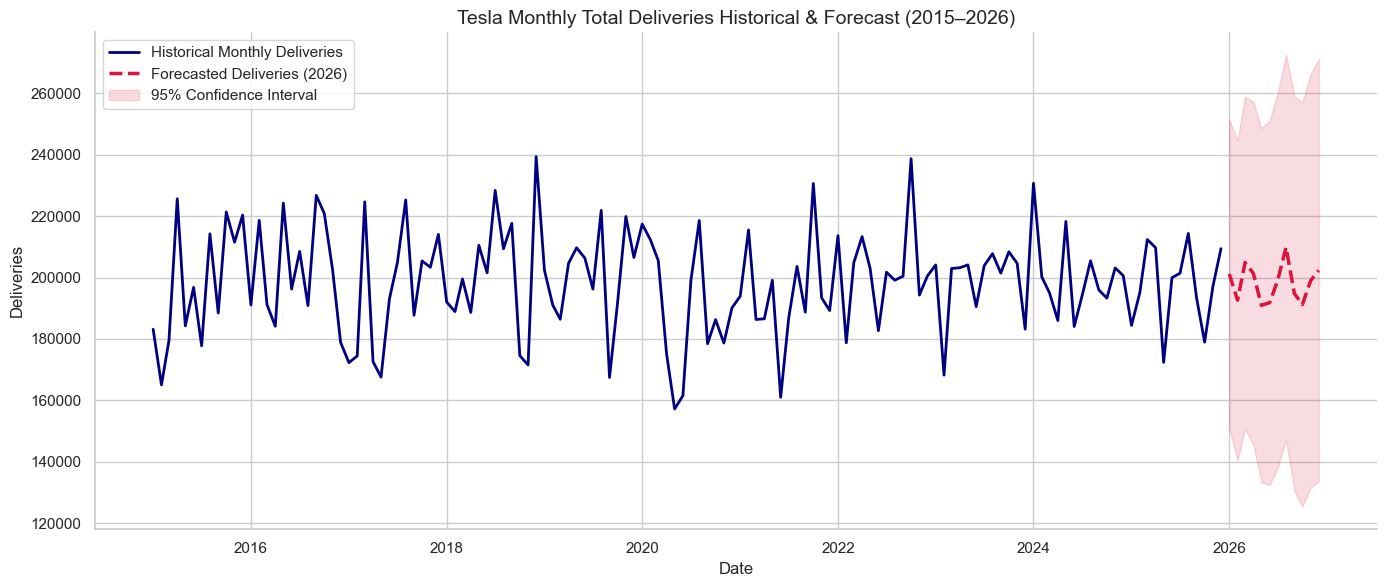

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(ts_data.index, ts_data.values, label='Historical Monthly Deliveries', color='navy', linewidth=2)
plt.plot(forecast_mean.index, forecast_mean.values, label='Forecasted Deliveries (2026)', color='crimson', linewidth=2.5, linestyle='--')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='crimson', alpha=0.15, label='95% Confidence Interval')

plt.title('Tesla Monthly Total Deliveries Historical & Forecast (2015–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()